# Regularization of linear regression with norms and constraints

## Steps

1. Repeat gradient descent with two (and more) variables
2. Regularization with the $L^2$ Norm
3. Parameter Tying with the $L^2$ Norm
4. Regularization with the $L^1$ Norm
5. Regularization with the $L^2$ Norm constraint
6. Regularization with the $L^1$ Norm constraint
7. Regularization of underconstraint problems

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from itertools import product

np.random.seed(42)

## Redefine all relevant functions from past notebook

Numerical Linear Regression.ipynb

(There are more to come...)

In [2]:
def rss2(a, b, X, Y):
    n = len(X)
    err = 0
    for i in range(n):
        err += (Y[i] - a*X[i] - b)**2
    return err

def grad_rss2(a, b, X, Y):
    n = len(X)
    grad_a = 0
    grad_b = 0
    for i in range(n):
        tmp = Y[i] - a*X[i] - b
        grad_a += tmp * X[i]
        grad_b += tmp
    grad_a = grad_a * -2
    grad_b = grad_b * -2
    grad_w = [grad_a, grad_b]
    return grad_w

def grad_desc_rss2(K, a0, b0, X, Y, learning_eps, f, ff, verbose):
    a = np.zeros((K+1,1))
    b = np.zeros((K+1,1))
    a[0] = a0
    b[0] = b0

    if verbose:
        plt.figure()
        plt.plot(a0, b0, "ro")

    for k in range(K):
        [grad_a, grad_b] = ff(a[k], b[k], X, Y)
        a[k+1] = a[k] - learning_eps * grad_a
        b[k+1] = b[k] - learning_eps * grad_b

        if verbose:
            plt.plot([a[k], a[k+1]], [b[k], b[k+1]], "r-")
            plt.plot(a[k+1], b[k+1], "ro", markersize=3)

    if verbose:
        alow = np.min(a)
        alow = np.min([alow, a0-2])
        ahigh = np.max(a)
        ahigh = np.max([ahigh, a0+2])
        blow = np.min(b)
        blow = np.min([blow, b0-6])
        bhigh = np.max(b)
        bhigh = np.max([bhigh, b0+6])
        [A, B] = np.meshgrid(np.linspace(alow, ahigh, 100), np.linspace(blow, bhigh, 100))
        plt.contour(A, B, f(A, B, X, Y), cmap="viridis")
        plt.show()
    
    return [a, b]

## Repeat gradient descent with two (and more) variables

Check the Notebook: "Numerical Linear Regression".

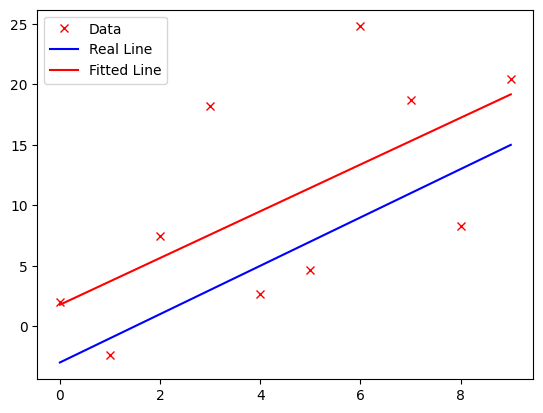

In [3]:
a0 = 2
b0 = -3

N = 10

X = np.arange(0, 10, 1)
Y = a0 * X + b0 + np.random.normal(0, 10, 10)

A, B = grad_desc_rss2(1000, a0, b0, X, Y, 0.001, rss2, grad_rss2, False)

fig, ax = plt.subplots()
ax.plot(X, Y, "rx", label="Data")
ax.plot(X, a0 * X + b0, "b-", label="Real Line")
ax.plot(X, A[-1] * X + B[-1], "r-", label="Fitted Line")
plt.legend()
plt.show()

We learn $\hat a$ and $\hat b$ from the data and expect them to be $\approx 2$ and $\approx -3$, respectively. 
Therefore, we minimize the residual sum of squares; $(\hat a, \hat b) = \arg \min_{a,b} RSS(a,b)=\sum_{i=1}^{n}(y_i- a x_i - b)^2$.  

Let's 3D plot the $RSS$ as a function of $a$ and $b$. We chose the ranges of $a$ and $b$ around the (actually unknown) minima of $\approx 2$ and $\approx -3$, respectively. 

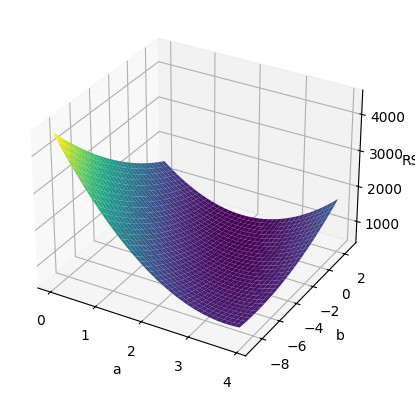

In [4]:
[A, B] = np.meshgrid(np.arange(a0-2, a0+2, 0.1,), np.arange(b0-6, b0+6, 0.4))


fig = plt.figure()
ax = plt.axes(projection="3d")
ax.plot_surface(A, B, rss2(A, B, X, Y), cmap="viridis")
ax.set_xlabel("a")
ax.set_ylabel("b")
ax.set_zlabel("RSS")
plt.show()

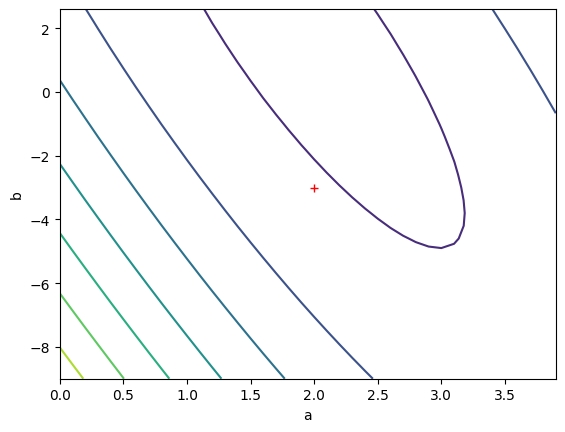

In [5]:
fig = plt.figure()
ax = plt.axes()
ax.contour(A, B, rss2(A, B, X, Y), cmap="viridis")
ax.plot(a0, b0, "r+")
ax.set_xlabel("a")
ax.set_ylabel("b")
plt.show()

The gradient of $RSS(a,b)$ for any $a, b$ is defiend as:

$$
\begin{aligned}
\nabla RSS(a,b) &= \left [ \frac{\partial RSS(a,b)}{\partial a}, \frac{\partial RSS(a,b)}{\partial b}\right ]^T\\
&= -2 \left [ \sum_{i=1}^{n}(y_i- a x_i-b)x_i, \sum_{i=1}^{n}(y_i- a x_i-b) \right ]^T 
\end{aligned}
$$

The gradient descent find the minimum.

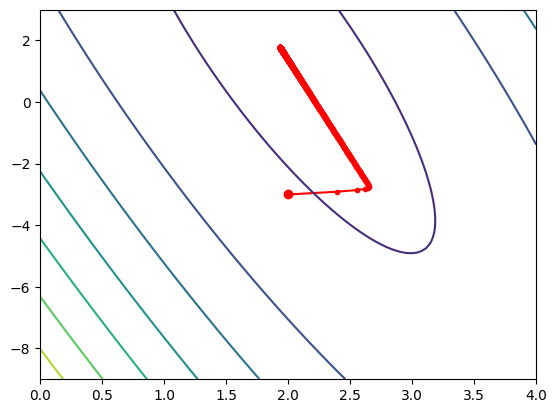

In [6]:
K = 1000
learning_eps = 0.001
# learning_eps = 0.0001
# learning_eps = 0.0025
# learning_eps = 0.00255

[a, b] = grad_desc_rss2(K, a0, b0, X, Y, learning_eps, rss2, grad_rss2, verbose=True)

Here the final result.

Orig: a=1.93 b=1.77 loss=[470.07488548]


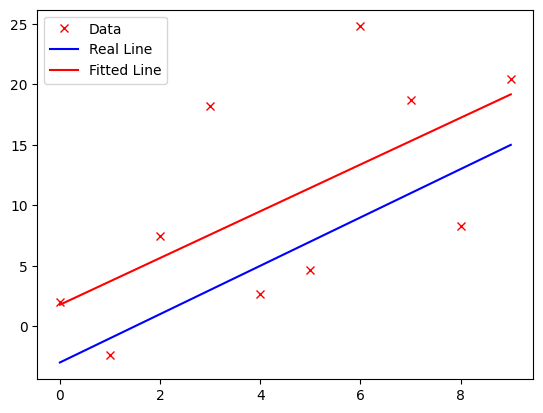

In [7]:
a_orig = a[0]
b_orig = b[0]

print(f"Orig: a={a[-1][0]:.2f} b={b[-1][0]:.2f} loss={rss2(a[-1], b[-1], X, Y)}")

fig, ax = plt.subplots()
ax.plot(X, Y, "rx", label="Data")
ax.plot(X, a0 * X + b0, "b-", label="Real Line")
ax.plot(X, a[-1] * X + b[-1], "r-", label="Fitted Line")
plt.legend()
plt.show()

## Regularization with the $L^2$ Norm

We add a penalty term to the loss function proportional to the square of the $L^2$ Norm of the parameters: $a^2 + b^2$. 

The regulated loss function is 
$$(\hat a, \hat b) = \arg \min_{a,b} RSS_{L^2}(a,b)=\sum_{i=1}^{n}(y_i- a x_i - b)^2 + \alpha(a^2 + b^2)$$
for some parameter $\alpha$.

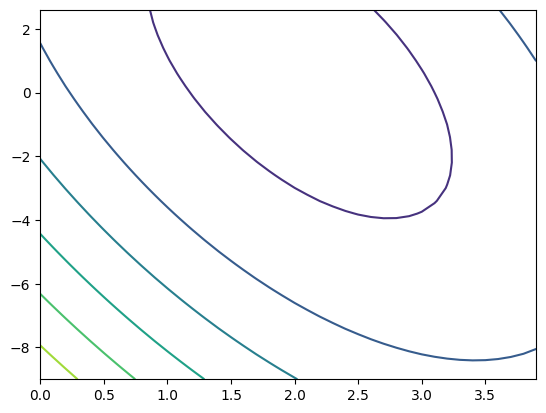

In [8]:
'''Here we show the loss function space when using the L2 norm as punishment'''

# alpha =0.1
# alpha =1
alpha =10

def L2(a, b, X, Y):
    return rss2(a, b, X, Y) + alpha*(a**2 + b**2)

[A,B] = np.meshgrid(np.arange(a0-2, a0+2, 0.1,), np.arange(b0-6, b0+6, 0.4))

fig, ax = plt.subplots()
ax.contour(np.arange(a0-2, a0+2, 0.1,), np.arange(b0-6, b0+6, 0.4), L2(A, B, X, Y))
plt.show()

The the new gradient of is:

$$
\begin{aligned}
\nabla RSS_{L^2}(a,b) 
&= \left [ \frac{\partial RSS_{L^2}(a,b)}{\partial a}, \frac{\partial RSS_{L^2}(a,b)}{\partial b}\right ]^T\\
&= \left [ \frac{\partial RSS(a,b)}{\partial a} +2\alpha a, \frac{\partial RSS(a,b)}{\partial b}+2\alpha b\right ]^T\\
&= \left [-2 \sum_{i=1}^{n}(y_i- a x_i-b)x_i +2 \alpha a, -2 \sum_{i=1}^{n}(y_i- a x_i-b) +2 \alpha b\right ]^T 
\end{aligned}
$$

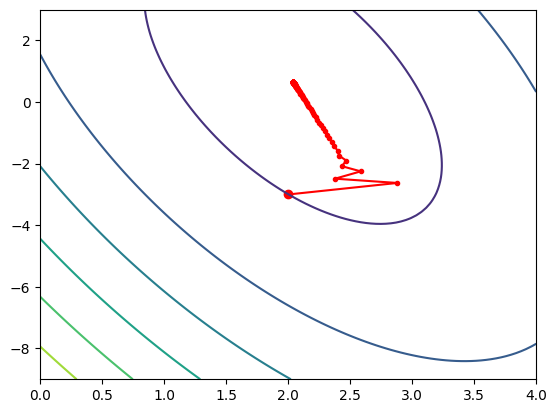

In [9]:
'''Here we see the path the regression took to find the minima'''

def grad_L2(a, b, X, Y):
    return grad_rss2(a, b, X, Y) + 2*alpha*np.array([a, b])

K = 1000
# learning_eps = 0.001
# learning_eps = 0.0001
learning_eps = 0.0025
# learning_eps = 0.00255

[aL2, bL2] = grad_desc_rss2(K, a0, b0, X, Y, learning_eps, L2, grad_L2, verbose=True)

L2: a=2.04 b=0.65 loss=[521.12823017]


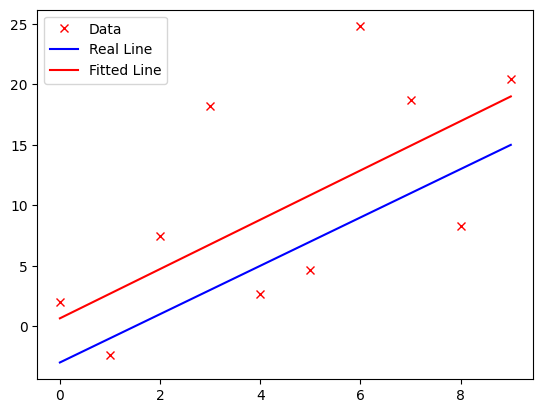

In [10]:
'''The found parameters compared to the original'''

print(f"L2: a={aL2[-1][0]:.2f} b={bL2[-1][0]:.2f} loss={L2(aL2[-1], bL2[-1], X, Y)}")

fig, ax = plt.subplots()
ax.plot(X, Y, "rx", label="Data")
ax.plot(X, a0 * X + b0, "b-", label="Real Line")
ax.plot(X, aL2[-1] * X + bL2[-1], "r-", label="Fitted Line")
plt.legend()
plt.show()

## Parameter Tying 

For demonstrating the approach, let's tie the parameters to the (usually unknown) gorund truth: $a_0 = 2,
b_0 = -3$. We add a penalty term to the loss function proportional to the square of the $L^2$ Norm of the parameters **difference** vector: $(a-a_0)^2 + (b-b_0)^2$. 

The regulated loss function is 
$$(\hat a, \hat b) = \arg \min_{a,b} RSS_{L^2, a_0, b_0}(a,b)=\sum_{i=1}^{n}(y_i- a x_i - b)^2 + \alpha((a-a_0)^2 + (b-b_0)^2)$$
for some parameter $\alpha$.

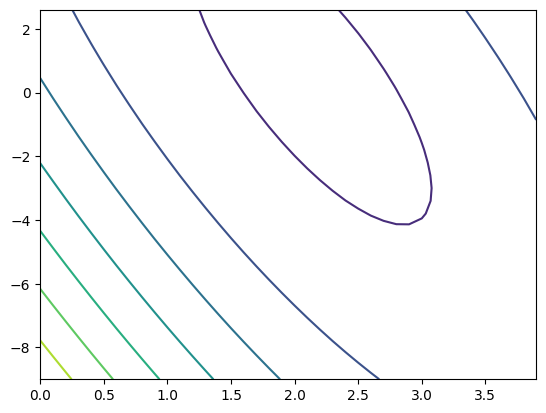

In [11]:
'''Here we show the loss function space when using parameter tying'''

alpha =1

def L2t(a, b, X, Y):
    return L2(a, b, X, Y) + alpha*((a-a0)**2 + (b-b0)**2)

[A, B] = np.meshgrid(np.arange(a0-2, a0+2, 0.1,), np.arange(b0-6, b0+6, 0.4))

fig, ax = plt.subplots()
ax.contour(np.arange(a0-2, a0+2, 0.1,), np.arange(b0-6, b0+6, 0.4), L2t(A, B, X, Y))
plt.show()

The the new gradient of is:

$$
\begin{aligned}
\nabla RSS_{L^2, a_0, b_0}(a,b) 
&= \left [ \frac{\partial RSS_{L^2, a_0, b_0}(a,b)}{\partial a}, \frac{\partial RSS_{L^2, a_0, b_0}(a,b)}{\partial b}\right ]^T\\
&= \left [ \frac{\partial RSS(a,b)}{\partial a} +2\alpha (a-a_0), \frac{\partial RSS(a,b)}{\partial b}+2\alpha (b - b_0)\right ]^T\\
&= \left [-2 \sum_{i=1}^{n}(y_i- a x_i-b)x_i +2 \alpha (a-a_0), -2 \sum_{i=1}^{n}(y_i- a x_i-b) +2 \alpha (b - b_0)\right ]^T 
\end{aligned}
$$

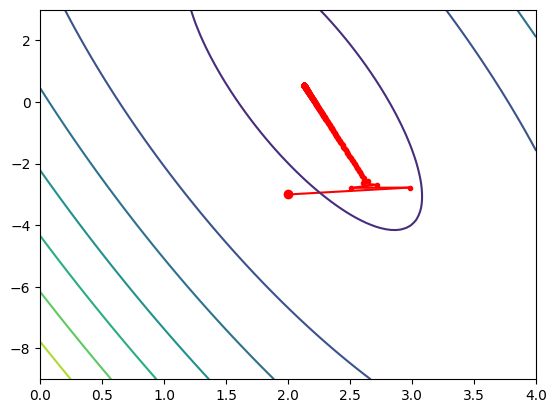

In [12]:
'''Here we see the path the regression took to find the minima'''

def grad_L2t(a, b, X, Y):
    return grad_rss2(a, b, X, Y) + 2*alpha*np.array([a-a0, b-b0])

K = 1000
# learning_eps = 0.001
# learning_eps = 0.0001
learning_eps = 0.0025
# learning_eps = 0.00255

[aL2t, bL2t] = grad_desc_rss2(K, a0, b0, X, Y, learning_eps, L2t, grad_L2t, verbose=True)

L2 tying: a=2.12 b=0.57 loss=[479.2507345]


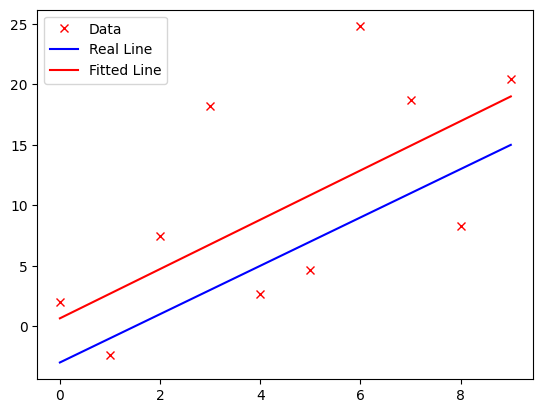

In [13]:
'''The found parameters compared to the original'''

print(f"L2 tying: a={aL2t[-1][0]:.2f} b={bL2t[-1][0]:.2f} loss={L2(aL2t[-1], bL2t[-1], X, Y)}")

fig, ax = plt.subplots()
ax.plot(X, Y, "rx", label="Data")
ax.plot(X, a0 * X + b0, "b-", label="Real Line")
ax.plot(X, aL2[-1] * X + bL2[-1], "r-", label="Fitted Line")
plt.legend()
plt.show()

## Regularization with the $L^1$ Norm

We add a penalty term to the loss function proportional to the $L^1$ Norm, i.e., sum of the absolute values of the parameters: $|a| + |b|$. 

The regulated loss function is now:
$$(\hat a, \hat b) = \arg \min_{a,b} RSS_{L^1}(a,b)=\sum_{i=1}^{n}(y_i- a x_i - b)^2 + \alpha(|a| + |b|)$$
for some parameter $\alpha$.

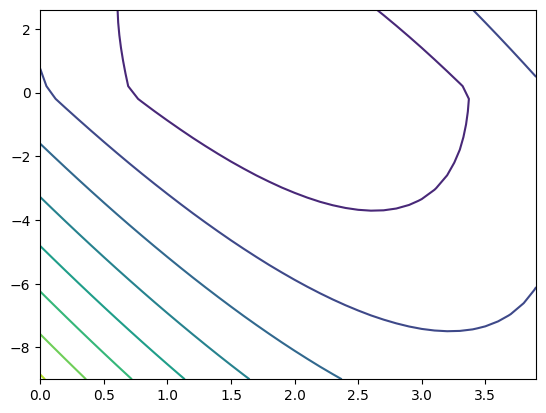

In [14]:
'''Here we show the loss function space when using the L1 norm as punishment'''

alpha = 100

def L1(a, b, X, Y):
    return rss2(a, b, X, Y) + alpha*(np.abs(a) + np.abs(b))

[A, B] = np.meshgrid(np.arange(a0-2, a0+2, 0.1,), np.arange(b0-6, b0+6, 0.4))

fig, ax = plt.subplots()
ax.contour(np.arange(a0-2, a0+2, 0.1,), np.arange(b0-6, b0+6, 0.4), L1(A, B, X, Y))
plt.show()

The the new gradient of is:

$$
\begin{aligned}
\nabla RSS_{L^1}(a,b) 
&= \left [ \frac{\partial RSS_{L^1}(a,b)}{\partial a}, \frac{\partial RSS_{L^1}(a,b)}{\partial b}\right ]^T\\
&= \left [ \frac{\partial RSS(a,b)}{\partial a} +\alpha\ \text{sign}(a), \frac{\partial RSS(a,b)}{\partial b}+\alpha\ \text{sign}(b)\right ]^T\\
&= \left [-2 \sum_{i=1}^{n}(y_i- a x_i-b)x_i +\alpha\ \text{sign}(a), -2 \sum_{i=1}^{n}(y_i- a x_i-b) +\alpha\   \text{sign}(b)\right ]^T 
\end{aligned}
$$

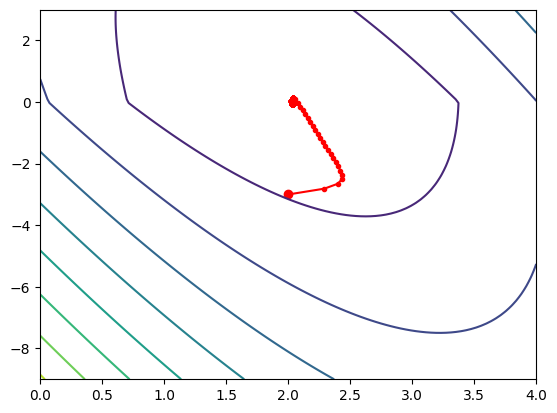

In [15]:
'''Here we see the path the regression took to find the minima'''

def grad_L1(a, b, X, Y):
    return grad_rss2(a, b, X, Y) + alpha*np.sign(np.array([a, b]))

K = 1000
learning_eps = 0.001
# learning_eps = 0.0001
# learning_eps = 0.0025
# learning_eps = 0.00255

[aL1, bL1] = grad_desc_rss2(K, a0, b0, X, Y, learning_eps, L1, grad_L1, verbose=True)

L1: a=2.03 b=0.01 loss=[692.3809554]


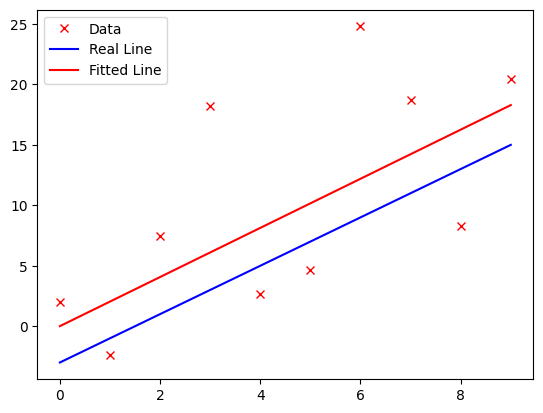

In [16]:
'''The found parameters compared to the original'''

print(f"L1: a={aL1[-1][0]:.2f} b={bL1[-1][0]:.2f} loss={L1(aL1[-1], bL1[-1], X, Y)}")

fig, ax = plt.subplots()
ax.plot(X, Y, "rx", label="Data")
ax.plot(X, a0 * X + b0, "b-", label="Real Line")
ax.plot(X, aL1[-1] * X + bL1[-1], "r-", label="Fitted Line")
plt.legend()
plt.show()

## 4. Regularization with the $L^2$ Norm constraint

### 4.1 The $L^2$ Norm equality constraint

A similar approach adds an equality constraint to the square of the $L^2$ Norm of the parameters: $a^2 + b^2$. 

This is actually not a real regularization that makes sense. However, the modifired loss function would be 
$$
\begin{aligned}
(\hat a, \hat b) = \arg \min_{a,b} RSS(a,b)&=\sum_{i=1}^{n}(y_i- a x_i - b)^2\\
\text{subject to } a^2 + b^2& = c
\end{aligned}
$$  
for some a constant $c$.

The equality constraint $(a^2 + b^2) = c$ is equal to the equality constraint $a^2 + b^2 - c = 0$. For the loss function with the equality constraint, we define the Lagrangian:

$$
\begin{aligned}
\mathcal{L}^2(a,b,\alpha) &= RSS(a,b) + \alpha(a^2 + b^2 -c)\\
&= \sum_{i=1}^{n}(y_i- a x_i - b)^2 + \alpha(a^2 + b^2 -c)
\end{aligned}
$$

The the gradient of is (now unconstraint) problem is:

$$
\begin{aligned}
\nabla \mathcal{L}^2(a,b,\alpha) 
&= \left [ \frac{\partial \mathcal{L}^2(a,b,\alpha)}{\partial a}, \frac{\partial \mathcal{L}^2(a,b,\alpha)}{\partial b}, \frac{\partial \mathcal{L}^2(a,b,\alpha)}{\partial \alpha} \right ]^T\\
&= \left [ 
\frac{\partial RSS(a,b)}{\partial a} + 2\alpha a, 
\frac{\partial RSS(a,b)}{\partial b} + 2\alpha b, 
a^2 + b^2 -c\right ]^T\\
&= \left [
-2 \sum_{i=1}^{n}(y_i- a x_i-b)x_i + 2 \alpha a, 
-2 \sum_{i=1}^{n}(y_i- a x_i-b) + 2 \alpha b, 
a^2 + b^2 -c\right ]^T 
\end{aligned}
$$

In [17]:
'''Here we define the loss function, gradient of the loss function and the iterative gradient descent'''

def L2_equality(a, b, alpha, c, X, Y):
    return rss2(a, b, X, Y) + alpha*(a**2 + b**2 - c)

def grad_L2_equality(a, b, alpha, c, X, Y):
    n = len(X)
    grad_a = 0
    grad_b = 0
    for i in range(n):
        tmp = Y[i] - a*X[i] - b
        grad_a += tmp * X[i]
        grad_b += tmp
    grad_a = grad_a * -2 + 2 * alpha * a
    grad_b = grad_b * -2 + 2 * alpha * b
    grad_alpha = a**2 + b**2 - c
    grad_w = [grad_a, grad_b, grad_alpha]
    return grad_w

def grad_desc_L2_equality(K, a0, b0, alpha0, c, learning_eps, f_orig, f, ff, verbose=False):
    a = np.zeros((K+1,1))
    b = np.zeros((K+1,1))
    alphas = np.zeros((K+1,1))
    a[0] = a0
    b[0] = b0
    alphas[0] = alpha0

    if verbose:
        plt.figure()
        plt.plot(a0, b0, "ro")

    for k in range(K):
        [grad_a, grad_b, grad_alpha] = ff(a[k], b[k], alphas[k], c, X, Y)
        a[k+1] = a[k] - learning_eps * grad_a
        b[k+1] = b[k] - learning_eps * grad_b
        alphas[k+1] = alphas[k] - learning_eps * grad_alpha

        if verbose:
            plt.plot([a[k], a[k+1]], [b[k], b[k+1]], "r-")
            plt.plot(a[k+1], b[k+1], "ro", markersize=3)

    if verbose:
        alow = np.min(a)
        alow = np.min([alow, a0-2])
        ahigh = np.max(a)
        ahigh = np.max([ahigh, a0+2])
        blow = np.min(b)
        blow = np.min([blow, b0-6])
        bhigh = np.max(b)
        bhigh = np.max([bhigh, b0+6])
        [A, B] = np.meshgrid(np.linspace(alow, ahigh, 100), np.linspace(blow, bhigh, 100))
        plt.contour(A, B, f_orig(A, B, X, Y), cmap="viridis")
        plt.show()
    
    return [a, b, alphas]

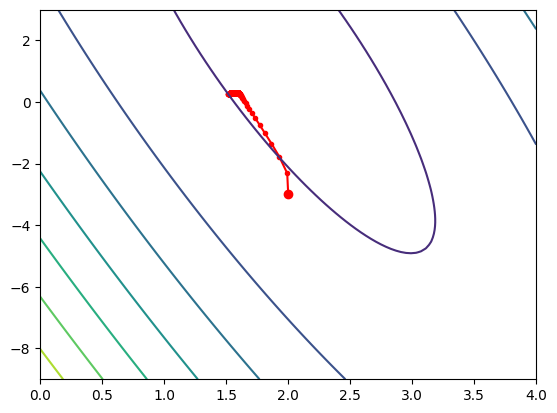

0.08216790831374965 0.019151216888360523 -22.619294549804525


In [18]:
'''Here we see the path the regression took to find the minima'''

K = 1000
learning_eps = 0.001
# learning_eps = 0.0001
# learning_eps = 0.0025
# learning_eps = 0.00255
c = 25

[ae, be, alphae] = grad_desc_L2_equality(K, a0, b0, alpha, c, learning_eps, rss2, L2_equality, grad_L2_equality, verbose=True)
temp_a, temp_b, temp_alpha = grad_L2_equality(ae[-1], be[-1], alphae[-1], c, X, Y)

print(temp_a[0], temp_b[0], temp_alpha[0])

L2 constraint: a=1.52 b=0.28 alpha=122.45 loss=[597.93314607]
a^2 + b^2 = 2.380705450195476; c=25


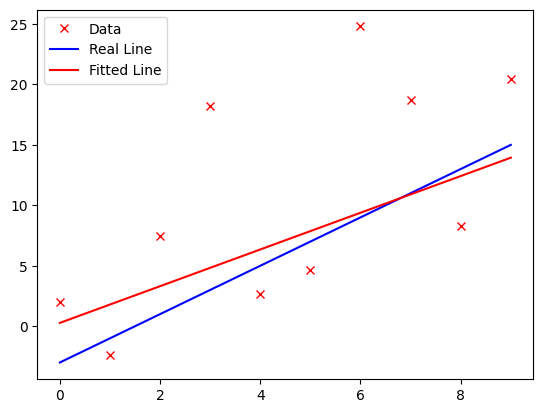

In [19]:
'''The found parameters compared to the original'''

print(f"L2 constraint: a={ae[-1][0]:.2f} b={be[-1][0]:.2f} alpha={alphae[-1][0]:.2f} loss={rss2(ae[-1], be[-1], X, Y)}")
print(f"a^2 + b^2 = {ae[-1][0]**2 + be[-1][0]**2}; c={c}")
fig, ax = plt.subplots()
ax.plot(X, Y, "rx", label="Data")
ax.plot(X, a0 * X + b0, "b-", label="Real Line")
ax.plot(X, ae[-1] * X + be[-1], "r-", label="Fitted Line")
plt.legend()
plt.show()

This does not seem to converge to a minumum: $a^2 + b^2 = 1 \neq c=25$. The problem is that when using Lagrange multipliers, the critical points don't occur at local minima of the Lagrangian - they occur at saddle points instead. Since the gradient descent algorithm is designed to find local minima, it fails to converge when we give it a problem with constraints.

Therefore, we optimize for the squared magnitude of the gradient, which is the sum of the squares of the partial derivatives. This is a transformation of the constraint problem such that the critical points occur at local minima. Details [here](https://en.wikipedia.org/wiki/Lagrange_multiplier#Example_4:_Numerical_optimization).

In our case the squared magnitude $M^2$ of the gradient $\nabla \mathcal{L}^2(a,b,\alpha)$ is:

$$
M^2(a,b,\alpha) = 
\left (-2 \sum_{i=1}^{n}(y_i- a x_i-b)x_i + 2 \alpha a \right)^2 +
\left (-2 \sum_{i=1}^{n}(y_i- a x_i-b) + 2 \alpha b \right)^2 +
\left ( \alpha (a^2 + b^2 -c) \right)^2 
$$

and its gradient is:

$$
\begin{align}
\nabla M^2(a,b,\alpha) &= 
\begin{bmatrix}
2\left (-2 \sum_{i=1}^{n}(y_i- a x_i-b)x_i + 2 \alpha a \right)\left (-2 \sum_{i=1}^{n}-x_i^2+ 2 \alpha \right) 
+ 2\left (-2 \sum_{i=1}^{n}(y_i- a x_i-b) + 2 \alpha b \right)\left (-2 \sum_{i=1}^{n}-x_i \right) 
    + 4\alpha^2 a(a^2 + b^2 -c) \\
2\left (-2 \sum_{i=1}^{n}(y_i- a x_i-b)x_i + 2 \alpha a \right)\left (-2 \sum_{i=1}^{n} -x_i \right) 
+ 2\left (-2 \sum_{i=1}^{n}(y_i- a x_i-b) + 2 \alpha b \right)\left (-2 \sum_{i=1}^{n} -1 + 2 \alpha \right) 
+ 4\alpha^2 b(a^2 + b^2 -c) \\
-8a \left (\sum_{i=1}^{n}(y_i- a x_i-b)x_i + 2 \alpha a \right) 
-8b \left (\sum_{i=1}^{n}(y_i- a x_i-b) + 2 \alpha b \right)
+2\alpha (a^2 + b^2 -c )^2
\end{bmatrix}
\\
&= 
\begin{bmatrix}
8\left (-\sum_{i=1}^{n}(y_i- a x_i-b)x_i + \alpha a \right)\left (\sum_{i=1}^{n}x_i^2+\alpha \right) 
+ 8\left (-\sum_{i=1}^{n}(y_i- a x_i-b) + \alpha b \right)\left (\sum_{i=1}^{n}x_i \right) 
    + 4\alpha^2 a(a^2 + b^2 -c) \\
8\left (-\sum_{i=1}^{n}(y_i- a x_i-b)x_i + \alpha a \right)\left (\sum_{i=1}^{n} x_i \right) 
+ 8\left (-\sum_{i=1}^{n}(y_i- a x_i-b) + \alpha b \right)\left (\sum_{i=1}^{n} 1 + \alpha \right) 
+ 4\alpha^2 b(a^2 + b^2 -c) \\
-8a \left (\sum_{i=1}^{n}(y_i- a x_i-b)x_i + 2 \alpha a \right) 
-8b \left (\sum_{i=1}^{n}(y_i- a x_i-b) + 2 \alpha b \right)
+2\alpha (a^2 + b^2 -c )^2
\end{bmatrix}
\end{align}$$

We don't want to further simplify this gradient nor use it to implement the optimization with gradient descent. Both is (error prone but) straight forward. 

See the "Constraint Optimization" notebook where we exercise this with a simpler optimization problem. 

### 4.2 Regularization with the $L^2$ Norm inequality constraint

A similar but not identical approach sets a **constraint** $c$ to the $L^2$ Norm of the parameters: $a^2 + b^2$. 

The regulated loss function is 
$$
\begin{aligned}
(\hat a, \hat b) = \arg \min_{a,b} RSS(a,b)&=\sum_{i=1}^{n}(y_i- a x_i - b)^2\\
\text{subject to } a^2 + b^2& \leq c
\end{aligned}
$$  
for some a constant $c$.

The inequality constraint $(a^2 + b^2) \leq c$ is equal to the equality constraint $a^2 + b^2 - c + s^2 = 0$, where $s$ is a new free variable. For the loss function with the equality constraint, we define the generalized Lagrangian:

$$
\begin{aligned}
\mathcal{L}^2(a,b,\alpha,s) &= RSS(a,b) + \alpha(a^2 + b^2 -c +s^2)\\
&= \sum_{i=1}^{n}(y_i- a x_i - b)^2 + \alpha(a^2 + b^2 -c +s^2)
\end{aligned}
$$

The gradient of is (now unconstraint) problem is:

$$
\begin{aligned}
\nabla \mathcal{L}^2(a,b,\alpha,s) 
&= \left [ \frac{\partial \mathcal{L}^2(a,b,\alpha,s)}{\partial a}, \frac{\partial \mathcal{L}^2(a,b,\alpha,s)}{\partial b}, \frac{\partial \mathcal{L}^2(a,b,\alpha,s)}{\partial \alpha}, \frac{\partial \mathcal{L}^2(a,b,\alpha,s)}{\partial s}\right ]^T\\
&= \left [ 
\frac{\partial RSS(a,b)}{\partial a} + 2\alpha a, 
\frac{\partial RSS(a,b)}{\partial b} + 2\alpha b, 
a^2 + b^2 -c +s^2, 
2\alpha s\right ]^T\\
&= \left [
-2 \sum_{i=1}^{n}(y_i- a x_i-b)x_i + 2 \alpha a, 
-2 \sum_{i=1}^{n}(y_i- a x_i-b) + 2 \alpha b, 
a^2 + b^2 -c +s^2, 
2\alpha s\right ]^T 
\end{aligned}
$$

In [20]:
'''Here we define the loss function, gradient of the loss function
and the iterative gradient descent with either L1/L2 regularization'''

def L2_inequality(a, b, alpha, s, c, X, Y):
    return rss2(a, b, X, Y) + alpha*(a**2 + b**2 - c + s**2)

def grad_L2_inequality(a, b, alpha, s, c, X, Y):
    n = len(X)
    grad_a = 0
    grad_b = 0
    for i in range(n):
        tmp = Y[i] - a*X[i] - b
        grad_a += tmp * X[i]
        grad_b += tmp
    grad_a = grad_a * -2 + 2 * alpha * a
    grad_b = grad_b * -2 + 2 * alpha * b
    grad_alpha = a**2 + b**2 - c + s**2
    grad_s = 2 * alpha * s
    grad_w = [grad_a, grad_b, grad_alpha, grad_s]
    return grad_w

def grad_desc_regression_inequality(K, a0, b0, alpha0, s0, c, learning_eps, f_orig, f, ff, verbose=False):
    a = np.zeros((K+1,1))
    b = np.zeros((K+1,1))
    alphas = np.zeros((K+1,1))
    s = np.zeros((K+1,1))
    a[0] = a0
    b[0] = b0
    alphas[0] = alpha0
    s[0] = s0

    if verbose:
        plt.figure()
        plt.plot(a0, b0, "ro")

    for k in range(K):
        [grad_a, grad_b, grad_alpha, grad_s] = ff(a[k], b[k], alphas[k], s[k], c, X, Y)
        a[k+1] = a[k] - learning_eps * grad_a
        b[k+1] = b[k] - learning_eps * grad_b
        alphas[k+1] = alphas[k] - learning_eps * grad_alpha
        s[k+1] = s[k] - learning_eps * grad_s

        if verbose:
            plt.plot([a[k], a[k+1]], [b[k], b[k+1]], "r-")
            plt.plot(a[k+1], b[k+1], "ro", markersize=3)

    if verbose:
        alow = np.min(a)
        alow = np.min([alow, a0-2])
        ahigh = np.max(a)
        ahigh = np.max([ahigh, a0+2])
        blow = np.min(b)
        blow = np.min([blow, b0-6])
        bhigh = np.max(b)
        bhigh = np.max([bhigh, b0+6])
        [A, B] = np.meshgrid(np.linspace(alow, ahigh, 100), np.linspace(blow, bhigh, 100))
        plt.contour(A, B, f_orig(A, B, X, Y), cmap="viridis")
        plt.show()
    
    return [a, b, alphas, s]

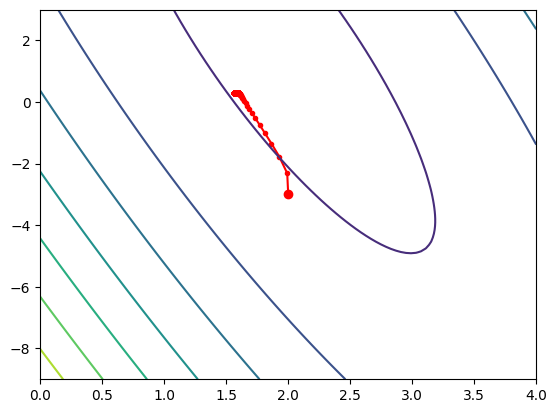

0.08216790831374965 0.019151216888360523 -10.619294549804524 6.78785830827068e-101


In [21]:
'''Here we see the path the regression took to find the minima'''

K = 1000
learning_eps = 0.001
# learning_eps = 0.0001
# learning_eps = 0.0025
# learning_eps = 0.00255
c = 13
s0 = 1

[ai, bi, alphai, si] = grad_desc_regression_inequality(K, a0, b0, alpha, s0, c, learning_eps, rss2, L2_inequality, grad_L2_inequality, verbose=True)
temp_a, temp_b, temp_alpha, temp_s = grad_L2_inequality(ae[-1], be[-1], alphae[-1], si[-1], c, X, Y)

print(temp_a[0], temp_b[0], temp_alpha[0], temp_s[0])

L2 constraint: a=1.56 b=0.29 alpha=110.38 s=0.00 loss=[597.93314607]
a^2 + b^2 = 2.5257171141724775; c=13


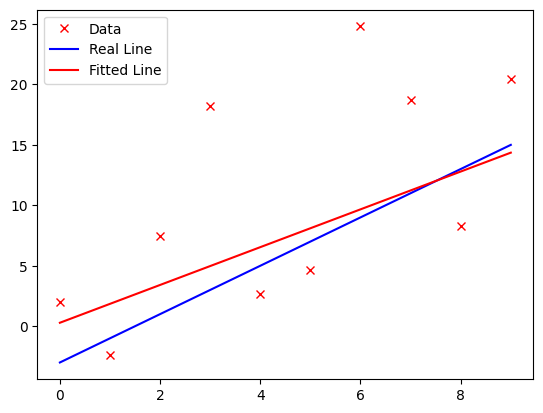

In [22]:
'''The found parameters compared to the original'''

print(f"L2 constraint: a={ai[-1][0]:.2f} b={bi[-1][0]:.2f} alpha={alphai[-1][0]:.2f} s={si[-1][0]:.2f} loss={rss2(ae[-1], be[-1], X, Y)}")
print(f"a^2 + b^2 = {ai[-1][0]**2 + bi[-1][0]**2}; c={c}")
fig, ax = plt.subplots()
ax.plot(X, Y, "rx", label="Data")
ax.plot(X, a0 * X + b0, "b-", label="Real Line")
ax.plot(X, ai[-1] * X + bi[-1], "r-", label="Fitted Line")
plt.legend()
plt.show()

Again, gradient descent does not seem to converge well since the critical points of Lagrangians occur at saddle points. Therefore, we solve the constraint optimization problem with the Karush–Kuhn–Tucker (KKT) approach. We need to check the KKT conditions:

$$
\begin{aligned}
\frac{\partial \mathcal{L}^2(a,b,\alpha,s)}{\partial a} &=0 \ \ \ \ \ (1)\\
-2 \sum_{i=1}^{n}(y_i- a x_i-b)x_i +2\alpha a&=0\\
\frac{\partial \mathcal{L}^2(a,b,\alpha,s)}{\partial b} &=0 \ \ \ \ \ (2)\\
-2 \sum_{i=1}^{n}(y_i- a x_i-b) +2\alpha b&=0 \\
\alpha (a^2 + b^2 - c) &=0 \ \ \ \ \ (3)
\end{aligned}
$$

We need to distinguish two cases for (3): 
- $\alpha = 0$ and $a^2 + b^2 - c < 0$, i.e., the constraint is inactive, (3a) 
- $\alpha > 0$ and $a^2 + b^2 - c = 0$, i.e., the constraint is active, (3b) 

Case (3a) reduces to the unconstraint problem, which we have solved already. The solution was $a\approx 2.49$ and $b\approx -8.44$. Checking the constraint on this solutions let's us conclude it is not $<0$ and, hence, the solution is not  feasible:

In [23]:
print(a_orig[0])
print(b_orig[0])
print("c =", ((a_orig+1)**2 + (b_orig+1)**2)[0]) # set randomly as a constraint (abs. values of a, b off by 1 from the act. unknown solution)
print(((a_orig)**2+(b_orig)**2-c)[0])

2.0
-3.0
c = 13.0
0.0


Case (3b) is equal to the equality constraint problem. It leads to the following system of equations that we can solve directly:

In [24]:
'''Here we solve a constrained optimization problem using numerical methods.

1. Generate multiple initial guesses (points on and inside the circle)
2. Solve numerically using fsolve for each guess to find roots of the three equations
3. Keep only valid solutions that satisfy the circle constraint
4. Check for deduplicate results to return unique solutions'''

def equations(vars):
    a, b, alpha = vars
    eq1 = -2 * np.sum((Y - a*X - b) * X) + 2*alpha*a
    eq2 = -2 * np.sum(Y - a*X - b) + 2*alpha*b
    eq3 = a**2 + b**2 - c
    return [eq1, eq2, eq3]

# Generate multiple initial guesses
n_guesses = 50
initial_guesses = []

for angle in np.linspace(0, 2*np.pi, n_guesses):
    a_guess = np.sqrt(c) * np.cos(angle)
    b_guess = np.sqrt(c) * np.sin(angle)
    alpha_guess = 0
    initial_guesses.append([a_guess, b_guess, alpha_guess])

# Also try points inside the circle
for a_guess in np.linspace(-np.sqrt(c), np.sqrt(c), 10):
    for b_guess in np.linspace(-np.sqrt(c), np.sqrt(c), 10):
        if a_guess**2 + b_guess**2 <= c:
            initial_guesses.append([a_guess, b_guess, 0])

# Remove duplicates and solve
solutions = []
tolerance = 1e-6

for guess in initial_guesses:
    try:
        sol = fsolve(equations, guess, full_output=True)
        if sol[2] == 1:  # Solution found
            a, b, alpha = sol[0]
            # Check if constraint is satisfied
            if abs(a**2 + b**2 - c) < tolerance:
                # Check if solution is unique (within tolerance)
                is_unique = True
                for existing_sol in solutions:
                    if (abs(a - existing_sol[0]) < tolerance and 
                        abs(b - existing_sol[1]) < tolerance):
                        is_unique = False
                        break
                if is_unique:
                    solutions.append([a, b, alpha])
    except:
        continue

# Convert to arrays
if solutions:
    a_hats = np.array([sol[0] for sol in solutions])
    b_hats = np.array([sol[1] for sol in solutions])
    alpha_hats = np.array([sol[2] for sol in solutions])
else:
    a_hats = np.array([])
    b_hats = np.array([])
    alpha_hats = np.array([])

There are several local optima fulfilling the constraint. Some are maybe local minima, some local maxima. We would need to check the second order condition involving the Hessian (deliberately omitted here). We just pick the solution with the minimum unregulated loss function (original $RSS$) value, which is $a\approx 1.93$ and $b\approx -4.61$ leading to $RSS\approx475.53$.

L2 constraint: a=2.64 b=-2.45 alpha=-4.28 loss=522.70
 feasible: a^2 + b^2 = 13.00 == c=13.00
L2 constraint: a=1.72 b=3.17 alpha=-1.38 loss=475.58
 feasible: a^2 + b^2 = 13.00 == c=13.00
L2 constraint: a=3.57 b=0.53 alpha=-114.78 loss=1062.59
 feasible: a^2 + b^2 = 13.00 == c=13.00
L2 constraint: a=-3.56 b=-0.58 alpha=-469.56 loss=10286.44
 feasible: a^2 + b^2 = 13.00 == c=13.00


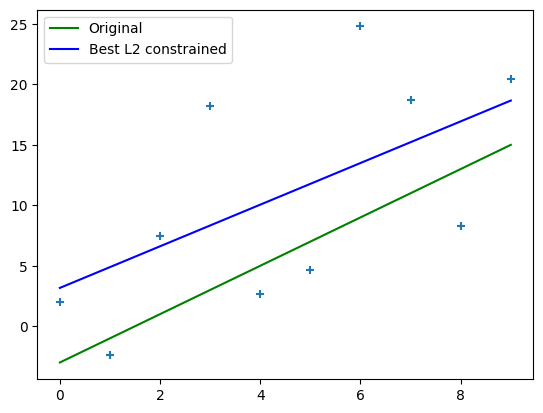

In [25]:
'''The found parameters compared to the original'''

# Find solution with minimum RSS
if len(a_hats) > 0:
    min_rss = np.inf
    arg_min = 0
    
    for i in range(len(a_hats)):
        a_hat = a_hats[i]
        b_hat = b_hats[i]
        alpha_hat = alpha_hats[i]
        rss = rss2(a_hat, b_hat, X, Y)
        
        if min_rss > rss:
            arg_min = i
            min_rss = rss
        
        print(f"L2 constraint: a={a_hat:.2f} b={b_hat:.2f} alpha={alpha_hat:.2f} loss={rss:.2f}")
        print(f" feasible: a^2 + b^2 = {a_hat**2 + b_hat**2:.2f} == c={c:.2f}")

    x_line = np.linspace(min(X), max(X), 100)

    plt.figure()
    plt.scatter(X, Y, marker='+')
    plt.plot(x_line, a0*x_line + b0, 'g', label='Original')
    plt.plot(x_line, a_hats[arg_min]*x_line + b_hats[arg_min], 'b', label='Best L2 constrained')
    plt.legend()
    plt.show()
else:
    print("No solutions found")

## Regularization with the $L^1$ Norm constraint

Finally we can set a constraint to the $L^1$ Norm of the parameters: $|a| + |b|$. 

The regulated loss function is 
$$
\begin{aligned}
(\hat a, \hat b) = \arg \min_{a,b} RSS(a,b)&=\sum_{i=1}^{n}(y_i- a x_i - b)^2\\
\text{subject to } |a| + |b|& \leq c
\end{aligned}
$$  
for some parameter $\alpha$ and a constant $c$.

The inequality constraint $|a| + |b| \leq c$ is equal to the equality constraint $|a| + |b| - c + s^2 = 0$. For the loss function with the equality constraint, we define the generalized Lagrangian:

$$
\begin{aligned}
\mathcal{L}^1(a,b,\alpha,s) &= RSS(a,b) + \alpha(|a| + |b| -c +s^2)\\
&= \sum_{i=1}^{n}(y_i- a x_i - b)^2 + \alpha(|a| + |b| -c +s^2)
\end{aligned}
$$

The the gradient of is (now unconstraint) problem is:

$$
\begin{aligned}
\nabla \mathcal{L}^1(a,b,\alpha,s) 
&= \left [ \frac{\partial \mathcal{L}^1(a,b,\alpha,s)}{\partial a}, \frac{\partial \mathcal{L}^1(a,b,\alpha,s)}{\partial b}, \frac{\partial \mathcal{L}^1(a,b,\alpha,s)}{\partial \alpha}, \frac{\partial \mathcal{L}^1(a,b,\alpha,s)}{\partial s}\right ]^T\\
&= \left [ \frac{\partial RSS(a,b)}{\partial a} +\alpha\ \text{sign}(a), \frac{\partial RSS(a,b)}{\partial b}+\alpha\ \text{sign}(b), |a| + |b| -c +s^2, 2\alpha s\right ]^T\\
&= \left [-2 \sum_{i=1}^{n}(y_i- a x_i-b)x_i +\alpha\ \text{sign}(a), -2 \sum_{i=1}^{n}(y_i- a x_i-b) +\alpha\ \text{sign}(b), |a| + |b| -c +s^2, 2\alpha s\right ]^T 
\end{aligned}
$$

In [26]:
'''Here we define the loss function and the gradient of the loss function'''

def L1_inequality(a, b, alpha, s, c, X, Y):
    return rss2(a, b, X, Y) + alpha*(np.abs(a) + np.abs(b) - c + s**2)

def grad_L1_inequality(a, b, alpha, s, c, X, Y):
    n = len(X)
    grad_a = 0
    grad_b = 0
    for i in range(n):
        tmp = Y[i] - a*X[i] - b
        grad_a += tmp * X[i]
        grad_b += tmp
    grad_a = grad_a * -2 + 2 * alpha * np.sign(a)
    grad_b = grad_b * -2 + 2 * alpha * np.sign(b)
    grad_alpha = np.abs(a) + np.abs(b) - c + s**2
    grad_s = 2 * alpha * s
    grad_w = [grad_a, grad_b, grad_alpha, grad_s]
    return grad_w

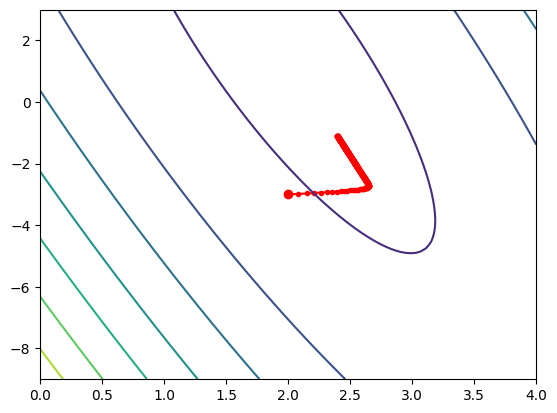

-1.336597132831563 -13.241965963938354 1.6414136129358927 -3.262271937942997


In [27]:
'''Here we see the path the regression took to find the minima'''

K = 500
learning_eps = 0.0002
c = (2+1) + (3+1)

[ai, bi, alphai, si] = grad_desc_regression_inequality(K, a0, b0, alpha, s0, c, learning_eps, rss2, L1_inequality, grad_L1_inequality, verbose=True)
temp_a, temp_b, temp_alpha, temp_s = grad_L2_inequality(ai[-1], bi[-1], alphai[-1], si[-1], c, X, Y)

print(temp_a[0], temp_b[0], temp_alpha[0], temp_s[0])

L1 constraint: a=2.40 b=-1.10 alpha=-1.25 s=1.30 loss=[597.93314607]
|a| + |b| = 6.942787755811655 < c=7


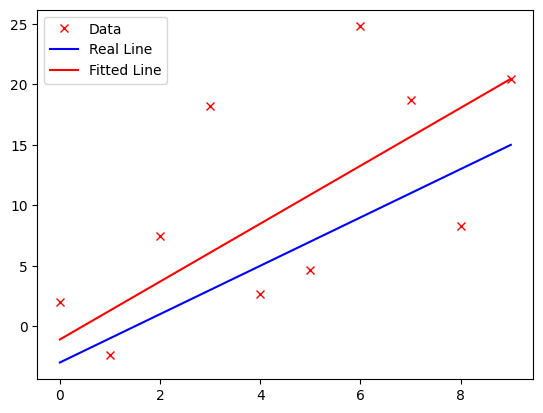

In [28]:
'''The found parameters compared to the original'''

print(f"L1 constraint: a={ai[-1][0]:.2f} b={bi[-1][0]:.2f} alpha={alphai[-1][0]:.2f} s={si[-1][0]:.2f} loss={rss2(ae[-1], be[-1], X, Y)}")
print(f"|a| + |b| = {ai[-1][0]**2 + bi[-1][0]**2} < c={c}")
fig, ax = plt.subplots()
ax.plot(X, Y, "rx", label="Data")
ax.plot(X, a0 * X + b0, "b-", label="Real Line")
ax.plot(X, ai[-1] * X + bi[-1], "r-", label="Fitted Line")
plt.legend()
plt.show()

Gradient descent does not seem to converge well. Even the constraint is violated. Therefore, we solve the constraint optimization problem with the Karush–Kuhn–Tucker (KKT) approach. Again, we need to check the KKT conditions:

$$
\begin{aligned}
\frac{\partial \mathcal{L}^1(a,b,\alpha,s)}{\partial a} &=0 \ \ \ \ \ (1)\\
-2 \sum_{i=1}^{n}(y_i- a x_i-b)x_i +\alpha\ \text{sign}(a) &=0\\
\frac{\partial \mathcal{L}^1(a,b,\alpha,s)}{\partial b} &=0 \ \ \ \ \ (2)\\
-2 \sum_{i=1}^{n}(y_i- a x_i-b) +\alpha\ \text{sign}(b) &=0 \\
\alpha (|a| + |b| - c) &=0 \ \ \ \ \ (3)
\end{aligned}
$$

We need to distinguish two cases for (3): 
- $\alpha = 0$ and $|a| + |b| - c < 0$, i.e., the constraint is inactive, (3a) 
- $\alpha > 0$ and $|a| + |b| - c = 0$, i.e., the constraint is active, (3b) 

Case (3a) reduces to the unconstraint problem, which we have solved: $a\approx 2.49$ and $b\approx -8.44$. Checking the constraint on this solutions let's us conclude it is not $<0$ and, hence, the solution is not  feasible:

In [29]:
print("a =", a_orig[0])
print("b =", b_orig[0])
print("c =", c)
print(f"|a| + |b| - c = {(np.abs(a_orig)+np.abs(b_orig)-c)[0]}")

a = 2.0
b = -3.0
c = 7
|a| + |b| - c = -2.0


Case (3b) leads to the following system of equations:

In [30]:
'''Here we solve a constrained optimization problem using numerical methods.

1. Generate multiple initial guesses (points on and inside the diamond)
2. Solve numerically using fsolve for each guess to find roots of the three equations
3. Keep only valid solutions that satisfy the diamond constraint
4. Check for deduplicate results to return unique solutions'''

def equations(vars):
    a, b, alpha = vars
    eq1 = -2 * np.sum((Y - a*X - b) * X) + alpha*np.sign(a)
    eq2 = -2 * np.sum(Y - a*X - b) + alpha*np.sign(b)
    eq3 = np.abs(a) + np.abs(b) - c
    return [eq1, eq2, eq3]

# Generate multiple initial guesses
n_guesses = 50
initial_guesses = []

for angle in np.linspace(0, 2*np.pi, n_guesses):
    a_guess = np.sqrt(c) * np.cos(angle)
    b_guess = np.sqrt(c) * np.sin(angle)
    alpha_guess = 0
    initial_guesses.append([a_guess, b_guess, alpha_guess])

# Also try points inside the circle
for a_guess in np.linspace(-np.sqrt(c), np.sqrt(c), 10):
    for b_guess in np.linspace(-np.sqrt(c), np.sqrt(c), 10):
        if a_guess**2 + b_guess**2 <= c:
            initial_guesses.append([a_guess, b_guess, 0])

# Remove duplicates and solve
solutions = []
tolerance = 1e-12

for guess in initial_guesses:
    try:
        sol = fsolve(equations, guess, full_output=True)
        if sol[2] == 1:  # Solution found
            a, b, alpha = sol[0]
            # Check if constraint is satisfied
            if abs(np.abs(a) + np.abs(b) - c) < tolerance:
                # Check if solution is unique (within tolerance)
                is_unique = True
                for existing_sol in solutions:
                    if (abs(a - existing_sol[0]) < tolerance and 
                        abs(b - existing_sol[1]) < tolerance):
                        is_unique = False
                        break
                if is_unique:
                    solutions.append([a, b, alpha])
    except:
        continue

# Convert to arrays
if solutions:
    a_hats = np.array([sol[0] for sol in solutions])
    b_hats = np.array([sol[1] for sol in solutions])
    alpha_hats = np.array([sol[2] for sol in solutions])
else:
    a_hats = np.array([])
    b_hats = np.array([])
    alpha_hats = np.array([])

L1 constraint: a=1.37 b=5.63 alpha=-26.38 loss=513.31
 feasible: |a| + |b| = 7.00 == c=7.00
L1 constraint: a=2.91 b=-4.09 alpha=-29.40 loss=570.92
 feasible: |a| + |b| = 7.00 == c=7.00


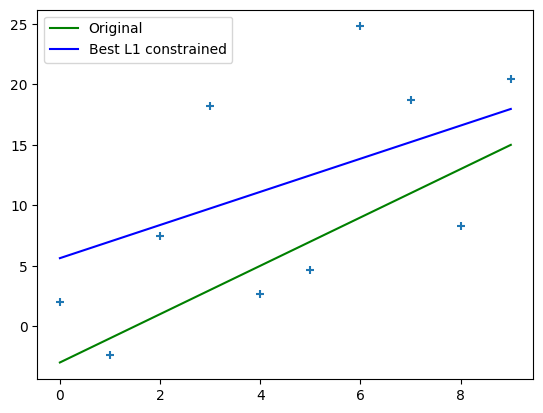

In [31]:
'''The found parameters compared to the original'''

# Find solution with minimum RSS
if len(a_hats) > 0:
    min_rss = np.inf
    arg_min = 0
    
    for i in range(len(a_hats)):
        a_hat = a_hats[i]
        b_hat = b_hats[i]
        alpha_hat = alpha_hats[i]
        rss = rss2(a_hat, b_hat, X, Y)
        
        if min_rss > rss:
            arg_min = i
            min_rss = rss
        
        print(f"L1 constraint: a={a_hat:.2f} b={b_hat:.2f} alpha={alpha_hat:.2f} loss={rss:.2f}")
        print(f" feasible: |a| + |b| = {np.abs(a_hat) + np.abs(b_hat):.2f} == c={c:.2f}")

    x_line = np.linspace(min(X), max(X), 100)

    plt.figure()
    plt.scatter(X, Y, marker='+')
    plt.plot(x_line, a0*x_line + b0, 'g', label='Original')
    plt.plot(x_line, a_hats[arg_min]*x_line + b_hats[arg_min], 'b', label='Best L1 constrained')
    plt.legend()
    plt.show()
else:
    print("No solutions found")

## Regularization of underconstraint problems

Let's look at a problem with two predictors and generate some test data. We set $a_1=a_2=2$ and $b=-3$ and generate $100$ datapoints $Y=a_1X_1+a_2X_2 + b$ where $X_1, X_2\in [1,10]$ with a random error that is normally distributed proportional to $\mathcal{N}(0,10)$. 

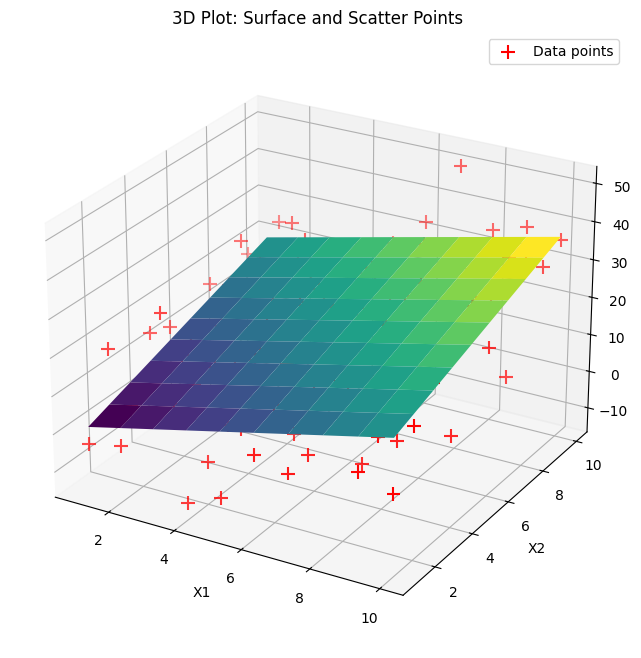

In [32]:
'''Here we create a 3d test dataset to test regularization on underconstrained problems'''

# Create the full factorial design matrix
XX = np.array(list(product(range(1, N+1), repeat=2)))
XX = np.fliplr(XX)

a10 = 2
a20 = 2
b0 = -3

# Extract columns
X1 = XX[:, 0]
X2 = XX[:, 1]

# Define functions
def f0(x1, x2):
    return a10 * x1 + a20 * x2 + b0

def f(x1, x2, r):
    return a10 * x1 + a20 * x2 + b0 + r

# Generate random noise
# normrnd(0, 10, 1, N*N) creates (N*N) samples with mean 0, std 10
R = np.random.normal(0, 10, N*N).reshape(-1, 1)

# Apply function element-wise
Y = np.array([f(x1, x2, r) for x1, x2, r in zip(X1, X2, R.flatten())])

# Create meshgrid for plotting the surface
A, B = np.meshgrid(np.arange(1, N+1), np.arange(1, N+1))

# Function to plot 3D surface (replacing plot3d)
def plot_3d_surface(func, A, B):
    """
    Plot a 3D surface from a function
    func: function that takes x1, x2 and returns z value
    A, B: meshgrid arrays
    """
    Z = func(A, B)
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(A, B, Z, alpha=1, cmap='viridis')
    return fig, ax

# Plot the surface
fig, ax = plot_3d_surface(f0, A, B)

# Plot the scatter points
ax.scatter(X1, X2, Y, color='red', marker='+', s=100, label='Data points')

# Add labels and title
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('Y')
ax.set_title('3D Plot: Surface and Scatter Points')
ax.legend()

# Adjust viewing angle
ax.view_init(elev=25, azim=-60)

plt.show()

Let's check the error $RSS_0$ for the initial parameters, learn new parameters from the generated data with linear regression minimizing $RSS$, and then check again this new error.

* $\verb|XS = np.column_stack([np.ones(N*N), XX])|$ Adds a bias term (column of 1's) to the design matrix XX. This makes XS a matrix of size (N*N*3), where the first column handles the intercept b0, and the rest are our features a10 and a20.

* $\verb|w0 = np.array([b0, a10, a20]).reshape(-1, 1)|$ is the weight vector for checking an initial guess.

* $\verb|residuals0 = Y_col - XS @ w0|$
$\newline \verb|RSS0 = residuals0.T @ residuals0| \newline$
computes the Residual Sum of Squares (RSS) for w0.

* $\verb|w = np.linalg.inv(XS.T @ XS) @ XS.T @ Y_col|$ is the closed-form solution for linear regression: $w=(X^T X)^{−1} X^T Y$ minimizes the Mean Squared Error (or equivalently, the RSS), giving the best-fitting line/hyperplane in the least-squares sense.

In [33]:
'''Explanation in previous markdown cell...'''

XS = np.column_stack([np.ones(N*N), XX])

w0 = np.array([b0, a10, a20]).reshape(-1, 1)

Y_col = Y.reshape(-1, 1)

residuals0 = Y_col - XS @ w0
RSS0 = residuals0.T @ residuals0

w = np.linalg.inv(XS.T @ XS) @ XS.T @ Y_col

residuals = Y_col - XS @ w
RSS = residuals.T @ residuals

print(f"RSS0 = {RSS0.item():.4f}")
print(f"\nEstimated parameters:")
print(f"  a1: {w[1, 0]:.4f}")
print(f"  a2: {w[2, 0]:.4f}")
print(f"  b: {w[0, 0]:.4f}")
print(f"\nTrue parameters:")
print(f"  a1: {w0[1, 0]:.4f}")
print(f"  a2: {w0[2, 0]:.4f}")
print(f"  b: {w0[0, 0]:.4f}")
print(f"\nRSS = {RSS.item():.4f}")

RSS0 = 8280.9010

Estimated parameters:
  a1: 1.7189
  a2: 2.5841
  b: -6.2025

True parameters:
  a1: 2.0000
  a2: 2.0000
  b: -3.0000

RSS = 7698.2947


We make it an underspecified problem by just keeping data points with $X_1=1$, i.e., we don't see any variability in this dimension. This makes $X^TX$ a singular matrix and, hence, not invertible. Analytically, we cannot find a solution any longer.

In [34]:
'''Here we change the first column of X to be all ones
and chect that it is indeed singular'''

uXX = XX[:N, :]

uY = Y[:N]

uXS = np.column_stack([np.ones(N), uXX])

uY_col = uY.reshape(-1, 1)
w0_col = w0.reshape(-1, 1)

residuals0 = uY_col - uXS @ w0_col
RSS0 = residuals0.T @ residuals0

try:
    w = np.linalg.inv(uXS.T @ uXS) @ uXS.T @ uY_col
except np.linalg.LinAlgError:
    print("The matrix uXS.T @ uXS is singular!")

The matrix uXS.T @ uXS is singular!


With the suggested regularization, $X^TX \rightarrow X^TX +\alpha I$ gets invertible and we find an approximate solution analytically.

In [35]:
'''Here we add the regularization term alpha to
slightly alter the matrix X to be invertible again'''

alpha = 0.1
I = np.eye(3)

uY_col = uY.reshape(-1, 1)

XTX = uXS.T @ uXS
XTX_reg = XTX + alpha * I
XTX_reg_inv = np.linalg.inv(XTX_reg)
w = XTX_reg_inv @ (uXS.T @ uY_col)

predictions = uXS @ w
residuals = uY_col - predictions
RSS = residuals.T @ residuals

print(f"\nEstimated parameters:")
print(f"  a1 = {w[1, 0]:.8f}")
print(f"  a2 = {w[2, 0]:.8f}")
print(f"  b = {w[0, 0]:.8f}")
print(f"\nRSS: {RSS.item():.6f}")


Estimated parameters:
  a1 = 1.52808640
  a2 = -3.13982964
  b = -3.13982964

RSS: 496.874961
